# ✈️ Airline Passenger Satisfaction Prediction

## 05. Model Evaluation

This notebook evaluates the trained Artificial Neural Network using multiple classification metrics and visualizations.

The evaluation includes:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC Curve and ROC-AUC
- Precision-Recall Curve and PR-AUC
- Classification Report
- Prediction Probability Analysis
- Classification Threshold Analysis
- Business Interpretation

In [1]:
# Step 2 : Importing Libraries

import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Step 3 : Loading the Processed Test Data

X_test = np.load("../data/processed/X_test.npy")
y_test = np.load("../data/processed/y_test.npy")

print("Test Features Shape:", X_test.shape)
print("Test Target Shape:", y_test.shape)

Test Features Shape: (25976, 27)
Test Target Shape: (25976,)


In [3]:
# Step 4 : Loading the Best ANN Model

model_path = "../models/best_airline_satisfaction_ann.keras"

model = tf.keras.models.load_model(model_path)

print("Best ANN model loaded successfully.")
print("Model Path:", model_path)

Best ANN model loaded successfully.
Model Path: ../models/best_airline_satisfaction_ann.keras


In [4]:
# Step 5 : Generating Prediction Probabilities

y_probability = model.predict(
    X_test,
    verbose=0
).ravel()

print("Prediction probabilities generated.")

print("\nFirst 10 probabilities:")
print(np.round(y_probability[:10], 4))

Prediction probabilities generated.

First 10 probabilities:
[9.907e-01 1.000e+00 8.000e-04 1.000e+00 2.244e-01 9.990e-01 1.000e+00
 1.000e+00 9.995e-01 1.000e+00]


In [5]:
# Step 6 : Converting Probabilities into Predictions

threshold = 0.50

y_pred = (
    y_probability >= threshold
).astype(int)

print("Classification Threshold:", threshold)

print("\nFirst 10 predictions:")
print(y_pred[:10])

Classification Threshold: 0.5

First 10 predictions:
[1 1 0 1 0 1 1 1 1 1]


In [6]:
# Step 7 : Verifying Target Classes

print("Actual Classes:")
print(np.unique(y_test))

print("\nPredicted Classes:")
print(np.unique(y_pred))

Actual Classes:
[0. 1.]

Predicted Classes:
[0 1]


In [7]:
# Step 8 : Calculating Accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", round(accuracy, 4))
print("Accuracy (%):", round(accuracy * 100, 2))

Accuracy: 0.9636
Accuracy (%): 96.36


In [8]:
# Step 9 : Calculating Precision

precision = precision_score(
    y_test,
    y_pred
)

print("Precision:", round(precision, 4))

Precision: 0.9717


In [9]:
# Step 10 : Calculating Recall

recall = recall_score(
    y_test,
    y_pred
)

print("Recall:", round(recall, 4))

Recall: 0.9447


In [10]:
# Step 11 : Calculating F1-Score

f1 = f1_score(
    y_test,
    y_pred
)

print("F1-Score:", round(f1, 4))

F1-Score: 0.958


In [11]:
# Step 12 : Calculating ROC-AUC

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", round(roc_auc, 4))

ROC-AUC: 0.9949


In [12]:
# Step 13 : Calculating PR-AUC

pr_auc = average_precision_score(
    y_test,
    y_probability
)

print("PR-AUC:", round(pr_auc, 4))

PR-AUC: 0.9941


In [13]:
# Step 14 : Generating Classification Report

class_names = [
    "neutral or dissatisfied",
    "satisfied"
]

classification_report_result = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

print(classification_report_result)

                         precision    recall  f1-score   support

neutral or dissatisfied       0.96      0.98      0.97     14573
              satisfied       0.97      0.94      0.96     11403

               accuracy                           0.96     25976
              macro avg       0.96      0.96      0.96     25976
           weighted avg       0.96      0.96      0.96     25976



In [14]:
# Step 15 : Creating Evaluation Metrics Table

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc
    ]
})

metrics_df["Score"] = metrics_df["Score"].round(4)

metrics_df

,Metric,Score
0,Accuracy,0.9636
1,Precision,0.9717
2,Recall,0.9447
3,F1-Score,0.9580
4,ROC-AUC,0.9949
5,PR-AUC,0.9941


In [15]:
# Step 16 : Calculating Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[14259   314]
 [  631 10772]]


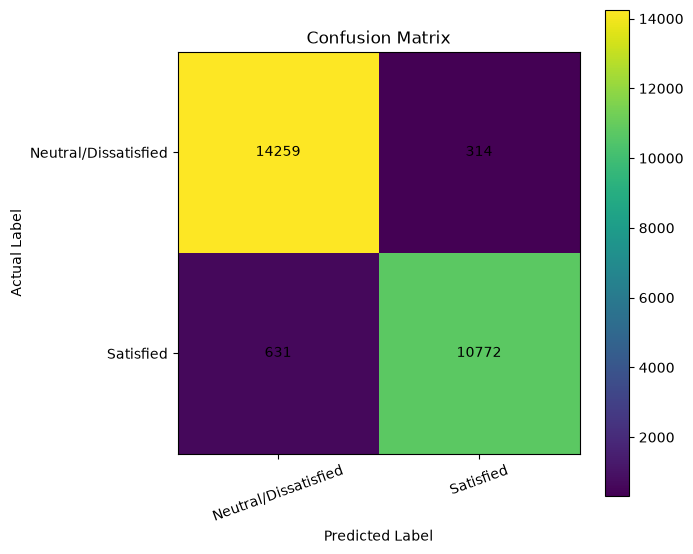

In [16]:
# Step 17 : Visualizing Confusion Matrix

plt.figure(figsize=(7, 6))

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Neutral/Dissatisfied", "Satisfied"],
    rotation=20
)

plt.yticks(
    [0, 1],
    ["Neutral/Dissatisfied", "Satisfied"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [17]:
# Step 18 : Extracting Confusion Matrix Components

tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives  :", tp)

True Negatives : 14259
False Positives: 314
False Negatives: 631
True Positives  : 10772


In [18]:
# Step 19 : Calculating Error Rates

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("False Positive Rate:", round(false_positive_rate, 4))
print("False Negative Rate:", round(false_negative_rate, 4))

False Positive Rate: 0.0215
False Negative Rate: 0.0553


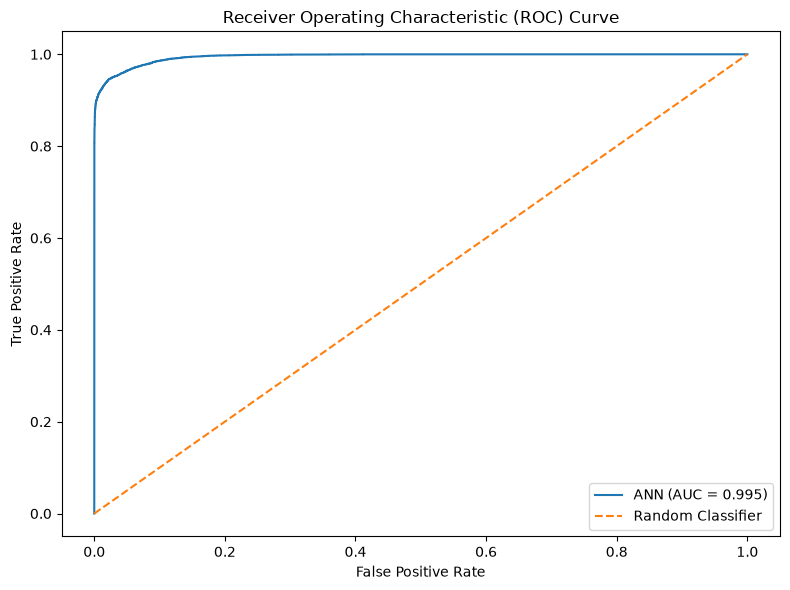

In [19]:
# Step 20 : Generating ROC Curve

fpr, tpr, roc_thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ANN (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

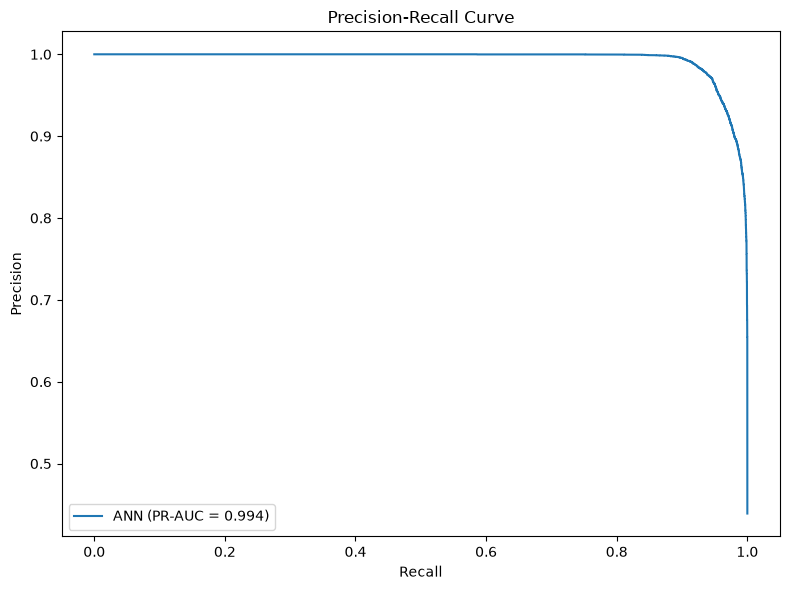

In [20]:
# Step 21 : Generating Precision-Recall Curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label=f"ANN (PR-AUC = {pr_auc:.3f})"
)

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.tight_layout()
plt.show()

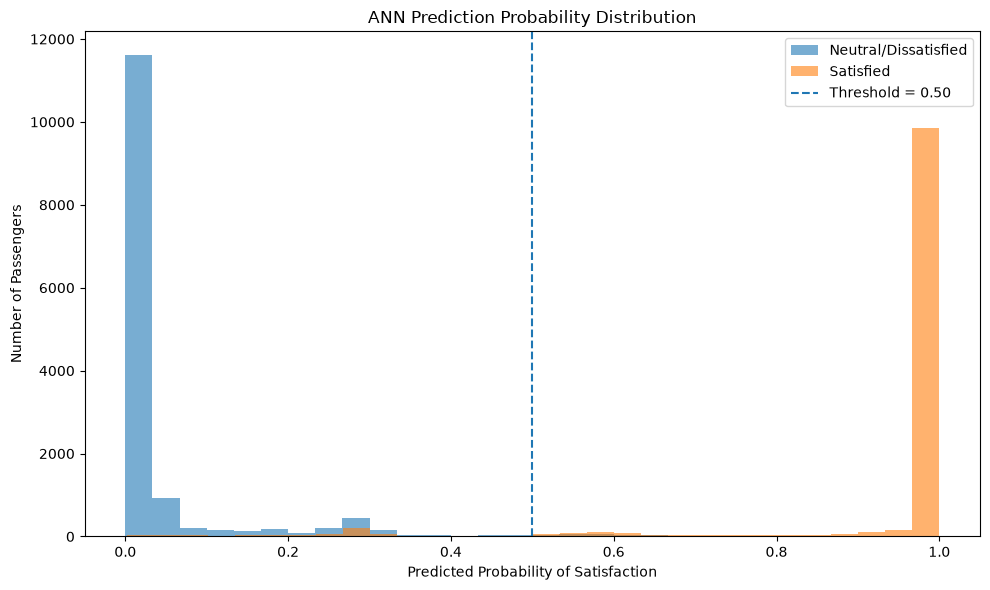

In [21]:
# Step 22 : Plotting Prediction Probability Distribution

plt.figure(figsize=(10, 6))

plt.hist(
    y_probability[y_test == 0],
    bins=30,
    alpha=0.6,
    label="Neutral/Dissatisfied"
)

plt.hist(
    y_probability[y_test == 1],
    bins=30,
    alpha=0.6,
    label="Satisfied"
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold = 0.50"
)

plt.title("ANN Prediction Probability Distribution")
plt.xlabel("Predicted Probability of Satisfaction")
plt.ylabel("Number of Passengers")
plt.legend()

plt.tight_layout()
plt.show()

In [22]:
# Step 23 : Analyzing Multiple Classification Thresholds

thresholds = [
    0.30,
    0.40,
    0.50,
    0.60,
    0.70
]

threshold_results = []

for threshold_value in thresholds:

    predictions = (
        y_probability >= threshold_value
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold_value,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.round(4)

,Threshold,Accuracy,Precision,Recall,F1-Score
0,0.3,0.9579,0.9457,0.9592,0.9524
1,0.4,0.9624,0.9644,0.9495,0.9569
2,0.5,0.9636,0.9717,0.9447,0.9580
3,0.6,0.9606,0.9841,0.9251,0.9537
4,0.7,0.9577,0.9916,0.9113,0.9497


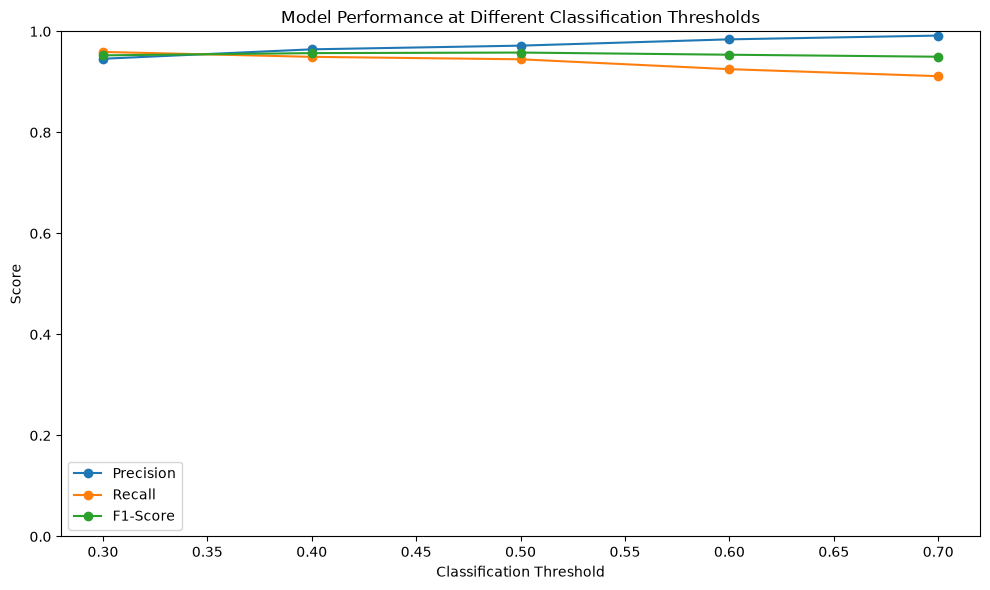

In [23]:
# Step 24 : Plotting Threshold Performance

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.title("Model Performance at Different Classification Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Step 25 : Finding Best F1 Threshold

best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]
best_threshold_f1 = best_threshold_row["F1-Score"]

print(
    "Best Threshold Based on F1-Score:",
    best_threshold
)

print(
    "Best F1-Score:",
    round(best_threshold_f1, 4)
)

Best Threshold Based on F1-Score: 0.5
Best F1-Score: 0.958


In [25]:
# Step 26 : Comparing Default and Best Threshold

default_predictions = (
    y_probability >= 0.50
).astype(int)

best_threshold_predictions = (
    y_probability >= best_threshold
).astype(int)

threshold_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Threshold 0.50": [
        accuracy_score(y_test, default_predictions),
        precision_score(y_test, default_predictions),
        recall_score(y_test, default_predictions),
        f1_score(y_test, default_predictions)
    ],
    f"Threshold {best_threshold:.2f}": [
        accuracy_score(y_test, best_threshold_predictions),
        precision_score(y_test, best_threshold_predictions),
        recall_score(y_test, best_threshold_predictions),
        f1_score(y_test, best_threshold_predictions)
    ]
})

threshold_comparison.round(4)

,Metric,Threshold 0.50
0,Accuracy,0.9636
1,Precision,0.9717
2,Recall,0.9447
3,F1-Score,0.9580


In [26]:
# Step 27 : Calculating Test Class Distribution

class_distribution = pd.Series(
    y_test
).value_counts()

class_distribution.index = [
    "Neutral/Dissatisfied" if index == 0 else "Satisfied"
    for index in class_distribution.index
]

print("Test Dataset Class Distribution:")
print(class_distribution)

print("\nClass Distribution Percentage:")
print(
    (class_distribution / len(y_test) * 100).round(2)
)

Test Dataset Class Distribution:
Neutral/Dissatisfied    14573
Satisfied               11403
Name: count, dtype: int64

Class Distribution Percentage:
Neutral/Dissatisfied    56.1
Satisfied               43.9
Name: count, dtype: float64


In [27]:
# Step 28 : Creating Final Evaluation Summary

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC",
        "PR-AUC",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc,
        pr_auc,
        false_positive_rate,
        false_negative_rate
    ]
})

evaluation_summary["Value"] = (
    evaluation_summary["Value"].round(4)
)

evaluation_summary

,Metric,Value
0,Accuracy,0.9636
1,Precision,0.9717
2,Recall,0.9447
3,F1-Score,0.9580
4,ROC-AUC,0.9949
5,PR-AUC,0.9941
6,False Positive Rate,0.0215
7,False Negative Rate,0.0553


In [28]:
# Step 29 : Saving Evaluation Results

os.makedirs(
    "../models/evaluation",
    exist_ok=True
)

evaluation_summary.to_csv(
    "../models/evaluation/evaluation_summary.csv",
    index=False
)

threshold_df.to_csv(
    "../models/evaluation/threshold_analysis.csv",
    index=False
)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [29]:
# Step 30 : Saving Test Predictions

prediction_results = pd.DataFrame({
    "Actual": y_test.astype(int),
    "Predicted Probability": y_probability,
    "Predicted Class": y_pred
})

prediction_results.to_csv(
    "../models/evaluation/test_predictions.csv",
    index=False
)

print("Test predictions saved successfully.")

Test predictions saved successfully.


# 💼 Business Interpretation

The ANN predicts whether an airline passenger is likely to be satisfied based on passenger characteristics, travel information, service ratings, and flight-related factors.

### How the model can support an airline

- Identify passengers who are likely to be dissatisfied.
- Understand the relationship between service quality and passenger satisfaction.
- Prioritize service improvements.
- Identify passengers who may require proactive customer-service attention.
- Support data-driven customer experience strategies.

### Important Evaluation Considerations

Accuracy provides an overall view of performance, but it should not be considered alone.

Precision indicates how reliable positive satisfaction predictions are.

Recall indicates how effectively the model identifies genuinely satisfied passengers.

F1-score balances precision and recall.

ROC-AUC measures the model's ability to rank the two classes across thresholds.

PR-AUC provides additional insight into the precision-recall trade-off.

Classification threshold selection can be adjusted depending on the airline's business objective.

# ✅ Model Evaluation Conclusion

The Artificial Neural Network was evaluated on the previously unseen test dataset using multiple classification metrics.

The evaluation covered:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC
- PR-AUC
- ROC Curve
- Precision-Recall Curve
- Prediction probability distribution
- Classification threshold analysis

The evaluation demonstrates not only the overall predictive performance of the ANN but also the types of errors made by the model and how its performance changes when the classification threshold is adjusted.

The final model and evaluation artifacts have been saved for use in the next stages of the project.


In [30]:
# Step 33 : Verifying Evaluation Files

evaluation_files = [
    "evaluation_summary.csv",
    "threshold_analysis.csv",
    "test_predictions.csv"
]

for file_name in evaluation_files:

    file_path = os.path.join(
        "../models/evaluation",
        file_name
    )

    print(
        f"{file_name}:",
        "Exists" if os.path.exists(file_path) else "Missing"
    )

evaluation_summary.csv: Exists
threshold_analysis.csv: Exists
test_predictions.csv: Exists
